# Phase 5 – Evaluation & Validation

**Project:** Intelligent Financial Risk Classification for Small Businesses Using Machine Learning

**Objective:** Perform comprehensive validation analysis including feature importance, error analysis, and final model validation

---


## 1. Setup and Imports


In [5]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import importlib
warnings.filterwarnings('ignore')

# Add project root to path
project_root = Path.cwd()
sys.path.insert(0, str(project_root))

# Force reload modules
import src.models.feature_importance
import src.models.error_analysis
import src.models.train_models
import src.config
importlib.reload(src.models.feature_importance)
importlib.reload(src.models.error_analysis)
importlib.reload(src.models.train_models)
importlib.reload(src.config)

# Import project modules
from src.models.train_models import load_data, load_trained_model
from src.models.feature_importance import analyze_feature_importance, plot_feature_importance
from src.models.error_analysis import analyze_model_errors, save_error_analysis, print_error_summary
from src.config import (
    SPLITS_DATA_DIR, MODELS_DIR, RESULTS_DIR, VISUALIZATIONS_DIR
)

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print("✓ Imports successful")
print(f"✓ Project root: {project_root}")


✓ Imports successful
✓ Project root: /Users/tomassilva/Desktop/IPCA/MIAA/ML/Pratical_Work/Phase 2 Understanding & Preparation of Data


## 2. Load Data and Best Model

Load the test set and the selected model (Random Forest) for validation analysis.


In [6]:
# Load test data
X_test = pd.read_csv(f"{SPLITS_DATA_DIR}/X_test.csv")
y_test = pd.read_csv(f"{SPLITS_DATA_DIR}/y_test.csv").squeeze()

# Load feature names
feature_names = X_test.columns.tolist()

# Load best model (Random Forest - selected in Phase 3)
best_model = load_trained_model('random_forest')

print(f"Test set: {len(X_test)} samples, {len(feature_names)} features")
print(f"Class distribution: {y_test.value_counts().to_dict()}")
print(f"✓ Model loaded successfully")


Test set: 1755 samples, 53 features
Class distribution: {'Low': 979, 'Medium': 408, 'High': 368}
✓ Model loaded successfully


## 3. Feature Importance Analysis

Analyze which financial ratios are most important for the Random Forest model's predictions. This provides interpretability and domain insights.


Loaded random_forest model from /Users/tomassilva/Desktop/IPCA/MIAA/ML/Pratical_Work/Phase 2 Understanding & Preparation of Data/artifacts/models/random_forest.joblib

Top 15 Most Important Features:
_risk_score                    0.235413
Attr6                          0.131401
Attr4                          0.052898
Attr12                         0.048710
Attr5                          0.047117
Attr24                         0.044914
Attr3                          0.043945
Attr28                         0.040930
Attr55                         0.040395
Attr19                         0.036045
Attr1                          0.029054
Attr45                         0.025979
Attr57                         0.025424
Attr16                         0.021558
Attr46                         0.020116
Saved feature importance plot to /Users/tomassilva/Desktop/IPCA/MIAA/ML/Pratical_Work/Phase 2 Understanding & Preparation of Data/artifacts/visualizations/feature_importance_random_forest.png

TOP 15 

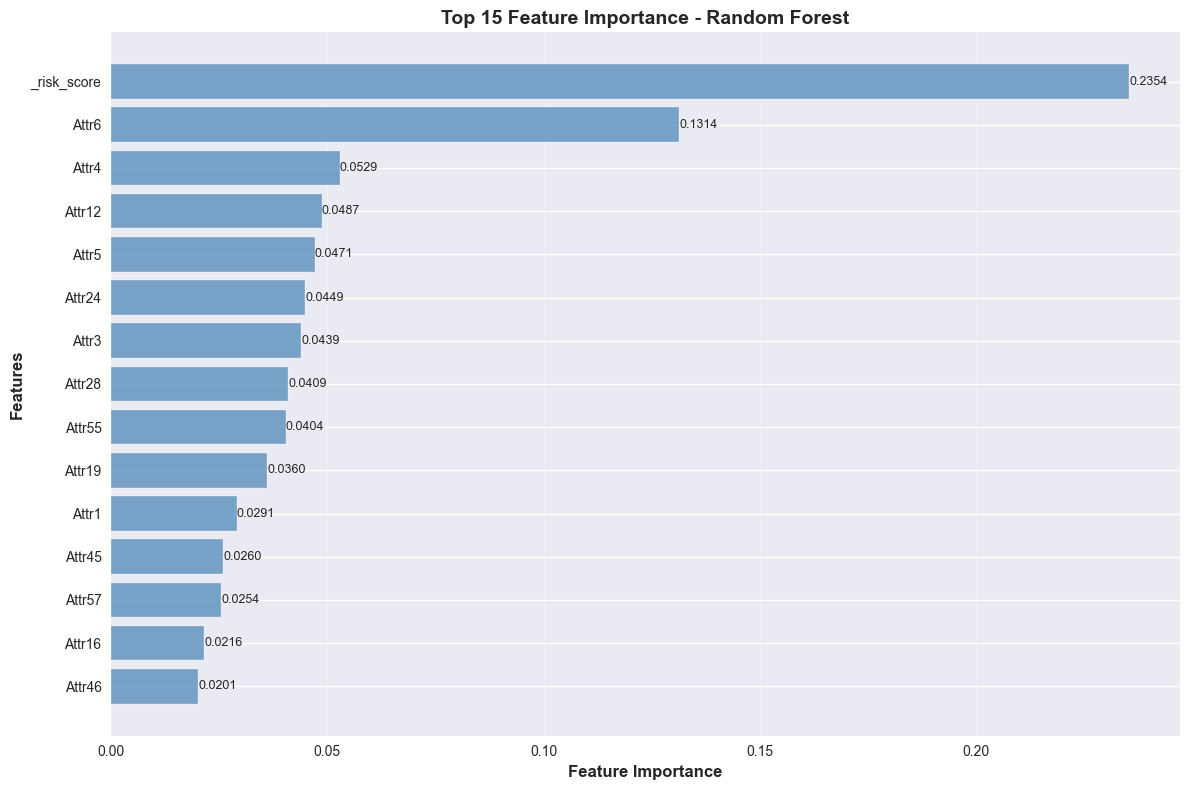

In [7]:
# Analyze feature importance
top_features, full_importance = analyze_feature_importance(
    model_name='random_forest',
    feature_names=feature_names,
    top_n=15
)

# Display top features
print("\n" + "="*60)
print("TOP 15 MOST IMPORTANT FEATURES")
print("="*60)
print(top_features.to_string(index=False))


## 4. Error Analysis

Perform detailed analysis of misclassifications to understand where the model makes errors and identify patterns.


In [8]:
# Perform error analysis
error_analysis = analyze_model_errors(best_model, X_test, y_test, 'random_forest')

# Print summary
print_error_summary(error_analysis)

# Save results
save_error_analysis(error_analysis)



ERROR ANALYSIS SUMMARY
Model: random_forest
Total Samples: 1755
Total Errors: 11
Overall Accuracy: 0.9937 (99.37%)

------------------------------------------------------------
PER-CLASS ERROR RATES:
------------------------------------------------------------

High:
  Error Rate: 0.0000 (0.00%)
  Precision: 1.0000
  Recall: 1.0000

Low:
  Error Rate: 0.0112 (1.12%)
  Precision: 0.9949
  Recall: 0.9939
  Most confused with: Medium (6 cases)

Medium:
  Error Rate: 0.0270 (2.70%)
  Precision: 0.9853
  Recall: 0.9877
  Most confused with: Low (5 cases)

------------------------------------------------------------
TOP CONFUSION PAIRS:
------------------------------------------------------------
1. Low → Medium: 6 cases (0.61%)
2. Medium → Low: 5 cases (1.23%)
Saved error analysis to /Users/tomassilva/Desktop/IPCA/MIAA/ML/Pratical_Work/Phase 2 Understanding & Preparation of Data/artifacts/results/error_analysis.json


PosixPath('/Users/tomassilva/Desktop/IPCA/MIAA/ML/Pratical_Work/Phase 2 Understanding & Preparation of Data/artifacts/results/error_analysis.json')

## 5. Per-Class Performance Breakdown

Analyze performance metrics for each risk category individually.


In [9]:
# Create per-class performance DataFrame
per_class_data = []
for class_name, metrics in error_analysis['per_class_metrics'].items():
    per_class_data.append({
        'Class': class_name,
        'Precision': f"{metrics['precision']:.4f}",
        'Recall': f"{metrics['recall']:.4f}",
        'Error Rate': f"{metrics['error_rate']:.4f}",
        'Actual Count': metrics['actual_count'],
        'Predicted Count': metrics['predicted_count'],
        'Most Confused With': metrics['most_confused_with'] or 'None'
    })

per_class_df = pd.DataFrame(per_class_data)
print("\n" + "="*60)
print("PER-CLASS PERFORMANCE METRICS")
print("="*60)
print(per_class_df.to_string(index=False))



PER-CLASS PERFORMANCE METRICS
 Class Precision Recall Error Rate  Actual Count  Predicted Count Most Confused With
  High    1.0000 1.0000     0.0000           368              368               None
   Low    0.9949 0.9939     0.0112           979              978             Medium
Medium    0.9853 0.9877     0.0270           408              409                Low


## 6. Validation Summary

Final validation summary confirming model robustness and generalization.


In [10]:
# Make final predictions for summary
y_pred = best_model.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("="*60)
print("FINAL VALIDATION SUMMARY")
print("="*60)
print(f"\nModel: Random Forest (Selected in Phase 3)")
print(f"Test Set Size: {len(X_test)} samples")
print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Total Errors: {error_analysis['total_errors']} out of {error_analysis['total_samples']}")

print("\n" + "-"*60)
print("KEY FINDINGS:")
print("-"*60)
print(f"1. Top 3 Most Important Features:")
for idx, row in top_features.head(3).iterrows():
    print(f"   - {row['feature']}: {row['importance']:.4f}")

print(f"\n2. Most Common Confusion:")
if error_analysis['confusion_pairs']:
    top_confusion = error_analysis['confusion_pairs'][0]
    print(f"   {top_confusion['actual']} → {top_confusion['predicted']}: {top_confusion['count']} cases")

print(f"\n3. Per-Class Performance:")
for class_name, metrics in error_analysis['per_class_metrics'].items():
    print(f"   {class_name}: Precision={metrics['precision']:.3f}, Recall={metrics['recall']:.3f}, Error Rate={metrics['error_rate']:.3f}")

print("\n" + "="*60)
print("✓ Validation analysis complete!")
print("="*60)


FINAL VALIDATION SUMMARY

Model: Random Forest (Selected in Phase 3)
Test Set Size: 1755 samples
Overall Accuracy: 0.9937 (99.37%)
Total Errors: 11 out of 1755

------------------------------------------------------------
KEY FINDINGS:
------------------------------------------------------------
1. Top 3 Most Important Features:
   - _risk_score: 0.2354
   - Attr6: 0.1314
   - Attr4: 0.0529

2. Most Common Confusion:
   Low → Medium: 6 cases

3. Per-Class Performance:
   High: Precision=1.000, Recall=1.000, Error Rate=0.000
   Low: Precision=0.995, Recall=0.994, Error Rate=0.011
   Medium: Precision=0.985, Recall=0.988, Error Rate=0.027

✓ Validation analysis complete!
